# Linear control systems and the Kalman rank condition

*Introduction to Control and Machine Learning · Part I: Control · Notebook 02*

> **Central question.** *When can a linear system with few controls be steered between arbitrary states?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 60–75 min · DEEPER LOOK and RESEARCH WINDOW ≈ 15 min more |
| **Execution time** | a few seconds |
| **Exercises** | 6 exercises, ≈ 60–120 min |
| **Prerequisites** | [notebook 01](01_control_fundamentals.ipynb) (the three control questions); matrix exponential, rank, kernel and range, the Cayley–Hamilton theorem |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 86–91, 99–102, 156–160, 28, 333–336 (see the Source map at the end) |
| **Notation** | `notation.md` §1; examples E1 and E2 as in §10 |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

**Learning objectives.** After this notebook you should be able to

1. solve $x'=Ax+Bu$ by variation of constants and describe the reachable set $\mathcal R(T,x^0)=e^{AT}x^0+\operatorname{Range}\mathcal K(A,B)$;
2. state the Kalman rank condition and prove it, both directions;
3. explain why controllability does not depend on $T$, while the difficulty of control does;
4. define the controllability Gramian, prove its basic properties, and use it to construct a control that steers $x^0$ to $x^1$;
5. distinguish the **algebraic** condition (a rank) from the **quantitative** question (how expensive control is, and in which directions).

## Where are we?
`CORE`

[Notebook 01](01_control_fundamentals.ipynb) separated three questions: controllability (*can* we reach a target?), optimal control (which control is *best*?) and stabilization (is there a *rule* that drives the system to rest?). This notebook answers the first question completely for **linear, finite-dimensional systems**. It is the setting where everything is explicit, and every later setting is measured against it.

## 1. Linear control systems
`CORE`

Let $n,m\ge1$ and $T>0$. We consider (PDF p. 87)

$$
x'(t)=Ax(t)+Bu(t),\quad t\in(0,T),\qquad x(0)=x^0,
$$

with $A\in\mathbb R^{n\times n}$, $B\in\mathbb R^{n\times m}$ and $x^0\in\mathbb R^n$. The state $x(t)$ has $n$ components and the control $u(t)$ has $m$. In practice $m\le n$, and often $m\ll n$: the most desirable situation is to control the system with as few controls as possible.

**Variation of constants.** Multiply the equation by $e^{-At}$:
$$
\big(e^{-At}x(t)\big)'=e^{-At}\big(x'(t)-Ax(t)\big)=e^{-At}Bu(t).
$$
Integrating from $0$ to $t$ and multiplying by $e^{At}$ gives (p. 88)

$$
x(t)=e^{At}x^0+\int_0^te^{A(t-s)}Bu(s)\,ds .
\tag{VC}
$$

For every $u\in L^2(0,T;\mathbb R^m)$ this defines the unique solution, which is continuous in time with square-integrable derivative ($x\in H^1(0,T;\mathbb R^n)$).

> **Definition (exact controllability, p. 88).** The system is **exactly controllable in time $T$** if for every $x^0,x^1\in\mathbb R^n$ there is $u\in L^2(0,T;\mathbb R^m)$ such that the solution satisfies $x(T)=x^1$.

The control process drives the solution from $x^0$ to $x^1$ in time $T$, by acting on the system through $u$.

## 2. Two first examples
`CORE`

**Example 1: an uncontrollable system (p. 89).** With $A=I_2$ and $B=\begin{pmatrix}1\\0\end{pmatrix}$, the system reads
$$
x_1'=x_1+u,\qquad x_2'=x_2\ \ \Longrightarrow\ \ x_2(t)=x_2^0e^t .
$$
The control does not act on the second component, which is completely determined by its initial value, so the system is not controllable.

**Example 2: the oscillator E1 is controllable (p. 90).** For $x_1''+x_1=u$, a direct argument works. Choose *any* smooth curve $x_1(t)$ with the prescribed position and velocity at $t=0$ and at $t=T$, and *define* the control afterwards:
$$
u(t)=x_1''(t)+x_1(t).
$$
By construction this $u$ steers the system between the prescribed states. For instance, to stop the oscillator, from $x^0=(1,0)$ to $x^1=(0,0)$ at $T=5$, the cubic $x_1(t)=1-3(t/T)^2+2(t/T)^3$ has the right boundary values. The same argument works for every scalar equation $x^{(n)}+a_{n-1}x^{(n-1)}+\dots+a_0x=u$ (Exercise 2).

> **Predict.** Is the control obtained in this way the *only* control that stops the oscillator at $T=5$?

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

from src.control_utils import (harmonic_oscillator, near_uncontrollable_system, kalman_matrix, kalman_rank,
                               kalman_singular_values, rank_tolerance, reachable_directions, gramian,
                               gramian_control, simulate, sample, time_grid, l2_norm)
from src.plotting_utils import apply_style, slope_guide, COLORS

apply_style()
rng = np.random.default_rng(seed=2)        # the only source of randomness in this notebook
np.set_printoptions(precision=5, suppress=True)

In [2]:
A, B = harmonic_oscillator()               # E1: x1'' + x1 = u
T = 5.0
x0 = np.array([1.0, 0.0])                  # displaced, at rest
x1 = np.array([0.0, 0.0])                  # at rest at the origin
t = time_grid(T, 2000)

# "Draw a curve, read off the control": cubic with x1(0)=1, x1'(0)=0, x1(T)=0, x1'(T)=0.
curve = lambda s: 1 - 3 * (s / T) ** 2 + 2 * (s / T) ** 3
curve_dd = lambda s: -6 / T**2 + 12 * s / T**3
u_curve = lambda s: np.array([curve_dd(s) + curve(s)])           # u = x1'' + x1

x_curve = simulate(A, B, u_curve, x0, T, t)
print("x(T) with the curve control:", x_curve[-1], "   L2 effort:", round(l2_norm(sample(u_curve, t), t), 4))

x(T) with the curve control: [-0. -0.]    L2 effort: 1.2137


## 3. The reachable set
`CORE`

The answer to the prediction is no: any other curve with the same boundary values gives another control. To organize all the possibilities, we collect the states that can be reached (p. 91):

$$
\mathcal R(T,x^0)=\big\{x(T)\;:\;x\text{ solves (VC) with some }u\in L^2(0,T;\mathbb R^m)\big\}.
$$

Exact controllability means $\mathcal R(T,x^0)=\mathbb R^n$ for every $x^0$.

By (VC), $x(T)=e^{AT}x^0+L_Tu$, with the linear **input-to-state map**
$$
L_T:L^2(0,T;\mathbb R^m)\to\mathbb R^n,\qquad L_Tu=\int_0^Te^{A(T-s)}Bu(s)\,ds .
$$
So $\mathcal R(T,x^0)=e^{AT}x^0+\operatorname{Range}L_T$ is an **affine subspace**: the free evolution of $x^0$, plus everything the control can add. The key fact is that the directions the control can add are described by a single matrix.

> **Definition (Kalman matrix).** $\mathcal K(A,B)=[\,B,\;AB,\;A^2B,\;\dots,\;A^{n-1}B\,]\in\mathbb R^{n\times nm}$.

> **Theorem 1 (reachable set).** *Assumptions:* $A\in\mathbb R^{n\times n}$, $B\in\mathbb R^{n\times m}$, $T>0$.
> *Conclusion:* $\operatorname{Range}L_T=\operatorname{Range}\mathcal K(A,B)$. Hence
> $$\mathcal R(T,x^0)=e^{AT}x^0+\operatorname{Range}\mathcal K(A,B)\qquad\text{for every }x^0\text{ and every }T>0 .$$
> *Interpretation:* the reachable set is an affine subspace whose direction does not depend on $T$ or $x^0$; only its offset $e^{AT}x^0$ does.

*Proof of "$\subseteq$" (Cayley–Hamilton, as on p. 159).* By the Cayley–Hamilton theorem, $A$ satisfies its characteristic polynomial, so $A^n$, and inductively every $A^j$ with $j\ge n$, is a linear combination of $I,A,\dots,A^{n-1}$. Hence every column of every $A^jB$ lies in $\operatorname{Range}\mathcal K$. The power series $e^{A(T-s)}B=\sum_{j\ge0}\frac{(T-s)^j}{j!}A^jB$ converges, and $\operatorname{Range}\mathcal K$ is closed, so each column of $e^{A(T-s)}B$ lies in $\operatorname{Range}\mathcal K$. Integrating against $u(s)$ keeps us there: $L_Tu\in\operatorname{Range}\mathcal K$.

The reverse inclusion "$\supseteq$" is proved in §6, with the Gramian. $\square$

**An uncontrollable example in three dimensions.** For E2 with $\varepsilon=0$ (see §8), $A=\begin{pmatrix}0&1&0\\-1&0&0\\0&0&-1\end{pmatrix}$ and $B_0=(0,1,0)^\top$. The actuator acts only on the oscillator, and $\operatorname{Range}\mathcal K=\{x_3=0\}$. From $x^0=(0,0,1)$ the reachable set is therefore the horizontal plane $\{x_3=e^{-T}\}$, whatever the control.

> **Predict.** Apply 60 different random controls to this system from $x^0=(0,0,1)$ for $T=5$, and plot the endpoints $x(T)$. What will the cloud of endpoints look like? And what changes if the actuator also reaches the third mode, $\varepsilon=0.3$?

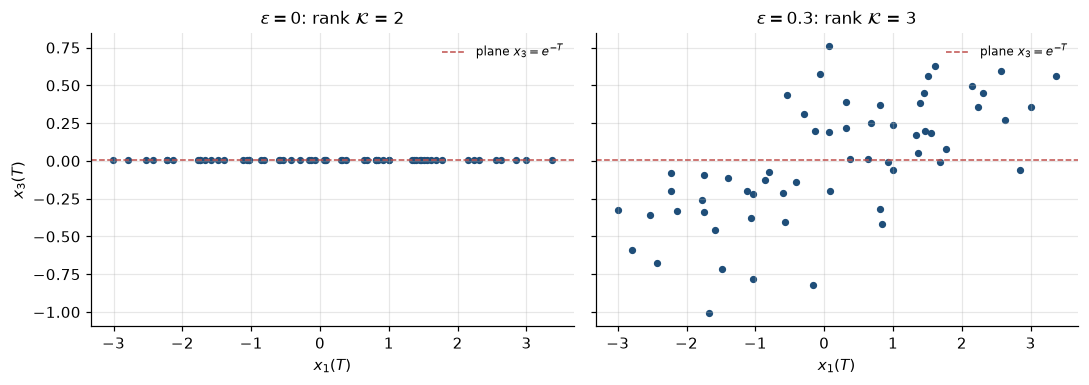

spread of x3(T) for eps = 0: 5.2880443079939e-14   (e^-T = 0.006737946999085467 )


In [3]:
def random_control(rng):
    c = rng.normal(size=4)
    return lambda s: np.array([c[0] + c[1] * np.sin(s) + c[2] * np.cos(2 * s) + c[3] * np.sin(3 * s)])

z0 = np.array([0.0, 0.0, 1.0])
controls = [random_control(rng) for _ in range(60)]
endpoints = {}
for eps in (0.0, 0.3):
    A2, B2 = near_uncontrollable_system(eps)
    endpoints[eps] = np.array([simulate(A2, B2, u, z0, T, [0.0, T])[-1] for u in controls])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, eps in zip(axes, (0.0, 0.3)):
    E = endpoints[eps]
    ax.scatter(E[:, 0], E[:, 2], s=14, color=COLORS["state"])
    ax.axhline(np.exp(-T), color=COLORS["control"], lw=1, ls="--", label=r"plane $x_3=e^{-T}$")
    ax.set_xlabel("$x_1(T)$"); ax.set_title(rf"$\varepsilon={eps:g}$: rank $\mathcal{{K}}$ = {kalman_rank(*near_uncontrollable_system(eps))}")
    ax.legend(fontsize=8)
axes[0].set_ylabel("$x_3(T)$")
plt.tight_layout(); plt.show()
print("spread of x3(T) for eps = 0:", np.ptp(endpoints[0.0][:, 2]), "  (e^-T =", np.exp(-T), ")")

**Figure 1.** Endpoints $x(T)$, projected on the $(x_1,x_3)$ plane, of the E2 system from $x^0=(0,0,1)$ with $T=5$, under the same 60 random controls. *Left:* $\varepsilon=0$, an uncontrollable pair. *Right:* $\varepsilon=0.3$, a controllable pair.

*Interpretation (answer to the prediction).* For $\varepsilon=0$ every endpoint has $x_3(T)=e^{-T}$, up to the ODE tolerance: the cloud is flat, as Theorem 1 predicts. No control can change the third component, which only decays by itself. For $\varepsilon=0.3$ the same controls spread the endpoints in all directions: a small coupling is enough to turn a plane of reachable states into all of $\mathbb R^3$. How *much* control a given direction requires is the quantitative question of §8.

## 4. The Kalman rank condition
`CORE`

Theorem 1 reduces controllability to linear algebra. The following classical result, due to R. E. Kalman, gives a complete answer for finite-dimensional linear systems (pp. 99, 157).

> **Theorem 2 (Kalman rank condition).** *Assumptions:* $A\in\mathbb R^{n\times n}$, $B\in\mathbb R^{n\times m}$.
> *Conclusion:* the system $x'=Ax+Bu$ is exactly controllable in some time $T>0$ if and only if
> $$\operatorname{rank}\,[\,B,\,AB,\,\dots,\,A^{n-1}B\,]=n .$$
> Consequently, if it is controllable in some time $T>0$, it is controllable in **every** time $T>0$.
> *Interpretation:* controllability is an algebraic property of the pair $(A,B)$ and does not depend on the horizon. How *expensive* control is does depend on $T$ (§8).

*Proof.* **Necessity.** If $\operatorname{rank}\mathcal K<n$, Theorem 1 ("$\subseteq$", already proved) gives $\mathcal R(T,x^0)\subseteq e^{AT}x^0+\operatorname{Range}\mathcal K\ne\mathbb R^n$, for every $T$: the system is not controllable.

**Sufficiency.** Assume $\operatorname{rank}\mathcal K=n$, and let $v\in\mathbb R^n$ be orthogonal to $\operatorname{Range}L_T$. We show $v=0$, so that $\operatorname{Range}L_T=\mathbb R^n$.

For every control, $0=\langle v,L_Tu\rangle=\int_0^T\big\langle B^*e^{A^*(T-s)}v,\,u(s)\big\rangle\,ds$. Choosing $u(s)=B^*e^{A^*(T-s)}v$ gives $\int_0^T|B^*e^{A^*(T-s)}v|^2\,ds=0$. The integrand is continuous, so
$$
g(s):=B^*e^{A^*(T-s)}v=0\qquad\text{for all }s\in[0,T].
$$
The function $g$ is analytic and vanishes identically, so all its derivatives vanish. At $s=T$, $g^{(j)}(T)=(-1)^jB^*(A^*)^jv=0$ for all $j\ge0$ (p. 100). In other words, $v$ is orthogonal to every column of $A^jB$, hence to $\operatorname{Range}\mathcal K=\mathbb R^n$, and $v=0$.

**Independence of $T$.** The rank condition does not involve $T$. $\square$

The function $g(s)=B^*e^{A^*(T-s)}v$ that appeared in the proof will be given a name, and a meaning, in notebook 03.

**Numerical rank.** In computations, "rank" means *numerical* rank: the number of singular values above a tolerance. We use the documented rule $\text{tol}=\max(\text{shape})\cdot\varepsilon_{\rm mach}\cdot s_{\max}$ (`rank_tolerance`), in double precision. The tolerance is a numerical decision, not a theorem: singular values close to it deserve a closer look (§5).

In [4]:
I2 = np.eye(2)
examples = {
    "Example 1: A = I, B = e1": (I2, np.array([[1.0], [0.0]])),
    "E1 oscillator": harmonic_oscillator(),
    "E2, eps = 0": near_uncontrollable_system(0.0),
    "E2, eps = 0.1": near_uncontrollable_system(0.1),
    "two identical oscillators, one input": (np.kron(I2, harmonic_oscillator()[0]),
                                             np.vstack([harmonic_oscillator()[1]] * 2)),
}
print(f"{'pair (A, B)':40s} n  rank K   singular values of K")
for name, (A_, B_) in examples.items():
    sv = kalman_singular_values(A_, B_)
    print(f"{name:40s} {A_.shape[0]}  {kalman_rank(A_, B_):4d}     {np.array2string(sv, precision=3)}"
          f"   (tol = {rank_tolerance(kalman_matrix(A_, B_)):.1e})")

pair (A, B)                              n  rank K   singular values of K
Example 1: A = I, B = e1                 2     1     [1.414 0.   ]   (tol = 6.3e-16)
E1 oscillator                            2     2     [1. 1.]   (tol = 4.4e-16)
E2, eps = 0                              3     2     [1.414 1.    0.   ]   (tol = 9.4e-16)
E2, eps = 0.1                            3     3     [1.414 1.005 0.141]   (tol = 9.4e-16)
two identical oscillators, one input     4     2     [2. 2. 0. 0.]   (tol = 1.8e-15)


The two uncontrollable cases are of different kinds. In Example 1 and in E2 at $\varepsilon=0$, a mode is simply not connected to the input. In the case of *two identical oscillators driven by the same input*, both oscillators are connected, but they respond identically, so no control can move them independently: the rank is 2, not 4. For E2 at $\varepsilon=0.1$ the rank is full, but one singular value is small. This is the difference between the algebraic answer and the quantitative one, the subject of §8.

## 5. Genericity, robustness and numerical rank
`DEEPER LOOK`

**Controllable pairs are open and dense (p. 102).** Controllability fails exactly when all $n\times n$ minors of $\mathcal K(A,B)$ vanish. Each minor is a polynomial in the entries of $(A,B)$. The set where finitely many polynomials vanish, not all of them identically zero, is closed and has empty interior. So controllability is **robust**: it survives small perturbations of $A$ and $B$. And it is **generic**: most systems are controllable, and an arbitrarily small perturbation makes an uncontrollable pair controllable. (In the robustness statement, controllability is a property of the *model*; it should not be confused with generalization in machine learning, a different notion met in [notebook 09](09_machine_learning_foundations_generalization.ipynb).)

**Cost estimate (p. 102).** When controllability holds, there is a control with $\|u\|_{L^2(0,T)}\le C\,|e^{AT}x^0-x^1|$, where $C$ depends on $(A,B,T)$. The size of $C$ is the quantitative side of controllability. The Gramian of §6 makes it computable.

**Rank is not a reliable measure of "how controllable".** By genericity, a random pair is controllable with probability one *if its entries have a joint distribution that is absolutely continuous with respect to Lebesgue measure* on the space of pairs $(A,B)$: the uncontrollable pairs form a proper algebraic subset, of Lebesgue measure zero. This fails for other distributions, for instance integer-valued or sparse entries, which can put positive probability on uncontrollable pairs. But a pair can be controllable *and* nearly uncontrollable, as E2 at $\varepsilon=0.1$ in the table above. Its numerical rank is full only because $\sqrt2\,\varepsilon$ is far above the tolerance. For $\varepsilon$ near $10^{-15}$ the numerical rank would drop to 2, although the algebraic rank is 3. The singular values tell more than the rank.

## 6. The controllability Gramian
`CORE`

The proof of Theorem 2 used the control $u(s)=B^*e^{A^*(T-s)}v$. Applying $L_T$ to controls of this form produces a matrix.

> **Definition (controllability Gramian).** $\displaystyle\mathcal G_T=\int_0^Te^{A(T-s)}BB^*e^{A^*(T-s)}\,ds\in\mathbb R^{n\times n}.$

> **Proposition 3 (properties of the Gramian).**
> 1. $\mathcal G_T$ is symmetric and positive semidefinite: $v^*\mathcal G_Tv=\int_0^T|B^*e^{A^*(T-s)}v|^2ds\ge0$.
> 2. $\ker\mathcal G_T=(\operatorname{Range}\mathcal K)^\perp$.
> 3. $\mathcal G_T$ is invertible if and only if $\operatorname{rank}\mathcal K=n$, that is, if and only if the system is controllable.
> 4. $L_T\big(B^*e^{A^*(T-\cdot)}c\big)=\mathcal G_Tc$ for every $c\in\mathbb R^n$.

*Proof.* (1) Symmetry is clear from the formula, and the identity follows from $v^*e^{A(T-s)}BB^*e^{A^*(T-s)}v=|B^*e^{A^*(T-s)}v|^2$.

(2) $\mathcal G_Tv=0$ implies $v^*\mathcal G_Tv=0$, hence $g(s)=B^*e^{A^*(T-s)}v\equiv0$, and the derivative argument in the proof of Theorem 2 gives $v\perp\operatorname{Range}\mathcal K$. Conversely, if $v\perp\operatorname{Range}\mathcal K$, then $v$ is orthogonal to every column of $e^{A(T-s)}B$ by the Cayley–Hamilton step of Theorem 1. So $g\equiv0$, and $\mathcal G_Tv=\int_0^Te^{A(T-s)}B\,g(s)\,ds=0$.

(3) follows from (2). (4) is the definition of $L_T$ applied to $u(s)=B^*e^{A^*(T-s)}c$. $\square$

**End of the proof of Theorem 1 ("$\supseteq$").** By (4), $\operatorname{Range}L_T\supseteq\operatorname{Range}\mathcal G_T$. By (2), and since $\mathcal G_T$ is symmetric, $\operatorname{Range}\mathcal G_T=(\ker\mathcal G_T)^\perp=\operatorname{Range}\mathcal K$. $\square$

## 7. An explicit steering control
`CORE`

If the system is controllable, property (4) tells us how to reach any target. We want $L_Tu=x^1-e^{AT}x^0$; try $u=B^*e^{A^*(T-\cdot)}c$ and solve $\mathcal G_Tc=x^1-e^{AT}x^0$:

$$
\boxed{\;u(t)=B^*e^{A^*(T-t)}\,\mathcal G_T^{-1}\big(x^1-e^{AT}x^0\big).\;}
\tag{G}
$$

*Verification.* By (VC) and the definition of $\mathcal G_T$,
$$
x(T)=e^{AT}x^0+\int_0^Te^{A(T-s)}BB^*e^{A^*(T-s)}\,ds\;\mathcal G_T^{-1}\big(x^1-e^{AT}x^0\big)=e^{AT}x^0+\big(x^1-e^{AT}x^0\big)=x^1 .
$$

We now compute (G) for E1, stopping the oscillator from $x^0=(1,0)$ at $T=5$, as in §2, and compare it with the control obtained from the cubic curve.

> **Predict.** Both controls stop the oscillator exactly. Which one do you expect to need less $L^2$ effort, $\|u\|_{L^2}=\big(\int_0^T|u|^2\big)^{1/2}$?

Kalman matrix K = [B, AB] =
 [[0. 1.]
 [1. 0.]] 
rank K = 2
Gramian G_T =
 [[2.63601 0.45977]
 [0.45977 2.36399]]
symmetric: True    eigenvalues: [2.02054 2.97946]

|x(T) - x1| with the Gramian control (G): 9.6e-12
L2 effort: Gramian control 0.6266   vs   cubic-curve control 1.2137


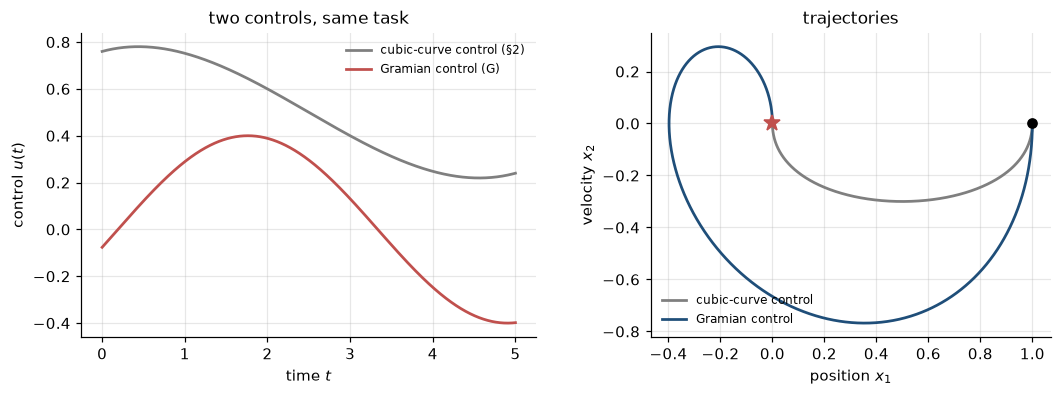

In [5]:
K = kalman_matrix(A, B)
G = gramian(A, B, T)
print("Kalman matrix K = [B, AB] =\n", K, "\nrank K =", kalman_rank(A, B))
print("Gramian G_T =\n", G)
print("symmetric:", np.allclose(G, G.T), "   eigenvalues:", np.linalg.eigvalsh(G))

u_G = gramian_control(A, B, T, x0, x1, G)
x_G = simulate(A, B, u_G, x0, T, t)
print(f"\n|x(T) - x1| with the Gramian control (G): {np.linalg.norm(x_G[-1] - x1):.1e}")
print(f"L2 effort: Gramian control {l2_norm(sample(u_G, t), t):.4f}   vs   cubic-curve control {l2_norm(sample(u_curve, t), t):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.7))
ax1.plot(t, sample(u_curve, t)[:, 0], color=COLORS["reference"], label="cubic-curve control (§2)")
ax1.plot(t, sample(u_G, t)[:, 0], color=COLORS["control"], label="Gramian control (G)")
ax1.set_xlabel("time $t$"); ax1.set_ylabel("control $u(t)$"); ax1.set_title("two controls, same task"); ax1.legend(fontsize=8)
ax2.plot(x_curve[:, 0], x_curve[:, 1], color=COLORS["reference"], label="cubic-curve control")
ax2.plot(x_G[:, 0], x_G[:, 1], color=COLORS["state"], label="Gramian control")
ax2.plot(*x0, "o", color="black"); ax2.plot(*x1, "*", ms=11, color=COLORS["control"])
ax2.set_xlabel("position $x_1$"); ax2.set_ylabel("velocity $x_2$"); ax2.set_aspect("equal")
ax2.set_title("trajectories"); ax2.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

**Figure 2.** Stopping E1 from $x^0=(1,0)$ at $T=5$. *Left:* the control $u=x_1''+x_1$ obtained from the cubic curve of §2, and the Gramian control (G). *Right:* the corresponding trajectories in the phase plane, both ending at the origin.

*Interpretation (answer to the prediction).* Both controls do the job exactly, so they are two points of the affine set of all controls described in §3. The Gramian control needs about half the $L^2$ effort of the curve control. It is also a pure sinusoid at the oscillator's own frequency. Neither fact has been explained yet; we return to them at the end of the notebook.

## 8. Quantitative controllability: the near-uncontrollable family E2
`CORE`

The Kalman condition is a yes/no answer. Notebook 01 showed with damping that "yes" can hide very different behaviours. Here is the analogue for controllability. The family E2 (`notation.md` §10) is

$$
A=\begin{pmatrix}0&1&0\\-1&0&0\\0&0&-1\end{pmatrix},\qquad B_\varepsilon=\begin{pmatrix}0\\1\\\varepsilon\end{pmatrix}.
$$

It couples the oscillator to a decaying mode $x_3'=-x_3+\varepsilon u$, which the actuator reaches with strength $\varepsilon$. A direct computation gives $\det\mathcal K(A,B_\varepsilon)=-2\varepsilon$, so the pair is controllable for every $\varepsilon\ne0$.

Using (G), the $L^2$ effort of that control for a displacement $d=x^1-e^{AT}x^0$ is $\big(d^*\mathcal G_T^{-1}d\big)^{1/2}$. We compare two targets reached from $x^0=0$: the **oscillator direction** $e_1$ and the **weak mode** $e_3$.

> **Predict.** As $\varepsilon\to0$: what happens to the smallest singular value of $\mathcal K$, to the smallest eigenvalue of $\mathcal G_T$, and to the effort needed to reach $e_1$ and $e_3$?

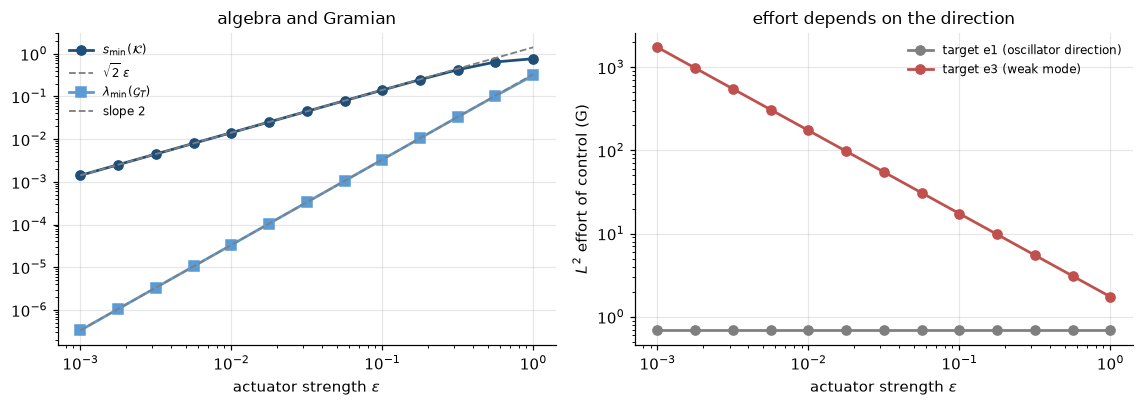

rank of K for every eps in the sweep: [3]


In [6]:
epsilons = np.logspace(-3, 0, 13)
targets = {"e1 (oscillator direction)": np.array([1.0, 0.0, 0.0]), "e3 (weak mode)": np.array([0.0, 0.0, 1.0])}
s_min, lam_min, effort = [], [], {name: [] for name in targets}
for eps in epsilons:
    A2, B2 = near_uncontrollable_system(eps)
    G2 = gramian(A2, B2, T)
    s_min.append(kalman_singular_values(A2, B2)[-1])
    lam_min.append(np.linalg.eigvalsh(G2)[0])
    for name, d_ in targets.items():
        effort[name].append(np.sqrt(d_ @ np.linalg.solve(G2, d_)))     # effort of control (G)
s_min, lam_min = np.array(s_min), np.array(lam_min)
effort = {name: np.array(v) for name, v in effort.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))
ax1.loglog(epsilons, s_min, "o-", color=COLORS["state"], label=r"$s_{\min}(\mathcal{K})$")
slope_guide(ax1, epsilons, np.sqrt(2) * epsilons[0], 1, r"$\sqrt{2}\,\varepsilon$")
ax1.loglog(epsilons, lam_min, "s-", color=COLORS["state2"], label=r"$\lambda_{\min}(\mathcal{G}_T)$")
slope_guide(ax1, epsilons, lam_min[0], 2, r"slope 2")
ax1.set_xlabel(r"actuator strength $\varepsilon$"); ax1.set_title("algebra and Gramian"); ax1.legend(fontsize=8)
for (name, values), color in zip(effort.items(), (COLORS["reference"], COLORS["control"])):
    ax2.loglog(epsilons, values, "o-", color=color, label=f"target {name}")
ax2.set_xlabel(r"actuator strength $\varepsilon$"); ax2.set_ylabel(r"$L^2$ effort of control (G)")
ax2.set_title(r"effort depends on the direction"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("rank of K for every eps in the sweep:", sorted({int(kalman_rank(*near_uncontrollable_system(e))) for e in epsilons}))

**Figure 3.** E2 with $T=5$ for $10^{-3}\le\varepsilon\le1$, on log–log axes. *Left:* the smallest singular value of the Kalman matrix and the smallest eigenvalue of the Gramian, with reference slopes. *Right:* the $L^2$ effort of the control (G) from $x^0=0$ to the targets $e_1$ and $e_3$.

*Interpretation (answer to the prediction).* The rank stays 3 throughout, so the algebraic answer is always "controllable". But $s_{\min}(\mathcal K)$ decays like $\varepsilon$ and $\lambda_{\min}(\mathcal G_T)$ like $\varepsilon^2$. The effort to reach the weak mode $e_3$ grows like $1/\varepsilon$, while the effort to reach the oscillator direction $e_1$ **does not change at all**. Control becomes expensive *in difficult directions*, not for every target. Notebook 03 explains where these rates come from and why the Gramian control is the natural one to measure.

> **Remark (what E2 does not show).** At $\varepsilon=0$, E2 loses controllability, but its uncontrollable mode $x_3'=-x_3$ is *stable*: it decays by itself. Losing controllability is therefore not the same as losing the ability to stabilize. For instance, the feedback $u=-B_0^*x$ gives the closed-loop eigenvalues $(-1\pm i\sqrt3)/2$ and $-1$. Stabilization is studied in [notebook 05](05_feedback_stabilization.ipynb).

### 8.1 Why these curves?
`DEEPER LOOK`

*The effort to reach $e_1$ is independent of $\varepsilon$.* A control steers $0$ to $e_1$ if and only if the oscillator part ends at $(1,0)$ and $x_3(T)=\varepsilon\int_0^Te^{-(T-s)}u(s)\,ds=0$. For $\varepsilon\ne0$ the second condition is $\int_0^Te^{-(T-s)}u\,ds=0$, which does not involve $\varepsilon$. The set of admissible controls, and hence the least effort among them, is the same for every $\varepsilon\ne0$. (That the control (G) attains this least effort is shown in notebook 03.)

*The effort to reach $e_3$ scales exactly like $1/\varepsilon$.* Now the oscillator part must end at $0$, a homogeneous condition, and $\varepsilon\int_0^Te^{-(T-s)}u\,ds=1$. Writing $u=v/\varepsilon$, the conditions on $v$ do not involve $\varepsilon$, so every admissible $u$ is $1/\varepsilon$ times an admissible $v$ for $\varepsilon=1$, and the *least* effort scales exactly like $1/\varepsilon$. The same holds for control (G), because notebook 03 proves it is the least-effort control; notebook 03 also computes the constant.

*$s_{\min}(\mathcal K)\approx\sqrt2\,\varepsilon$* (a standard perturbation fact, used here as a pedagogical addition). $\mathcal K(A,B_\varepsilon)=\mathcal K_0+\varepsilon E$ with $\mathcal K_0=\mathcal K(A,B_0)$ of rank 2. For a simple zero singular value with unit right and left null vectors $v$ and $w$ of $\mathcal K_0$, $s_{\min}(\mathcal K_0+\varepsilon E)=\varepsilon\,|w^*Ev|+O(\varepsilon^2)$. Here $v=(1,0,1)/\sqrt2$, $w=e_3$ and $E=e_3\,(1,-1,1)$, so $w^*Ev=\sqrt2$.

## 9. Control ↔ ML: one system or many?
`CORE` · *Forward connection*

Classical controllability asks whether **one system** can be steered by **its control**: the Kalman theorem answers how many states $n$ a few controls $m$ can handle (pp. 87, 333). In the machine-learning part of the course the question is turned around. Supervised learning is read as **simultaneous** (ensemble) control: *many* trajectories, one per data point, steered by *one shared* control, the parameters of the network (p. 336). The rank argument of this notebook does not apply there, and different, geometric constructions are needed ([notebook 14](14_classification_as_simultaneous_control.ipynb)).

## 10. Beyond linear systems
`RESEARCH WINDOW`

For nonlinear systems, controllability can come from *combining* motions rather than from a rank test on $(A,B)$. The classical illustration is **Nelson's car** (pp. 160, 334): two controls, steering and driving, suffice to control a four-dimensional state, consisting of the position, the orientation of the car and the angle of the wheels. This is the parking manoeuvre mentioned on p. 28. The mathematics behind it is the theory of Lie brackets, which the slides cite (Sontag's *Mathematical Control Theory*) but do not develop. It reappears, in a different form, in the classification results of [notebook 14](14_classification_as_simultaneous_control.ipynb).

## 11. Common misconceptions
`CORE`

**"With fewer controls than states, a system cannot be controllable."** E1 has one control and two states, and it is controllable. What matters is how $A$ propagates the action of $B$, which is exactly what $\mathcal K$ records.

**"Controllability in a longer time is easier, so it can hold for large $T$ and fail for small $T$."** For linear systems the property does not depend on $T$ (Theorem 2). The *cost* of control does depend on $T$.

**"Full rank means control is easy."** E2 has full rank for every $\varepsilon>0$, yet some targets become very expensive (§8). The rank is an algebraic yes/no; the Gramian measures the difficulty.

**"Uncontrollable means unstable."** E2 at $\varepsilon=0$ is uncontrollable, but its uncontrollable mode decays by itself (§8).

**"The control that reaches the target is unique."** The set of controls is an affine space (§3). Figure 2 shows two different controls for the same task.

## 12. What you should remember
`CORE`

1. Variation of constants: $x(T)=e^{AT}x^0+L_Tu$ with $L_Tu=\int_0^Te^{A(T-s)}Bu(s)\,ds$.
2. Reachable set: $\mathcal R(T,x^0)=e^{AT}x^0+\operatorname{Range}\mathcal K(A,B)$, an affine subspace whose direction does not depend on $T$.
3. Kalman: controllable ⟺ $\operatorname{rank}[B,AB,\dots,A^{n-1}B]=n$; and then controllable in every time $T>0$.
4. The proof uses Cayley–Hamilton (necessity) and the vanishing of all derivatives of $B^*e^{A^*(T-s)}v$ at $s=T$ (sufficiency).
5. Gramian: $\mathcal G_T$ is symmetric, positive semidefinite, with $\ker\mathcal G_T=(\operatorname{Range}\mathcal K)^\perp$; it is invertible iff the system is controllable.
6. Formula (G) steers $x^0$ to $x^1$ exactly.
7. The rank is algebraic; singular values and Gramian eigenvalues measure how hard control is, direction by direction.

## 13. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★ (predict the rank).** *Without computing*, predict whether each pair is controllable, then check with `kalman_rank`: (a) the double integrator $A=\begin{pmatrix}0&1\\0&0\end{pmatrix}$, $B=\begin{pmatrix}0\\1\end{pmatrix}$; (b) $A=\operatorname{diag}(1,2)$, $B=\begin{pmatrix}1\\1\end{pmatrix}$; (c) $A=I_2$, $B=\begin{pmatrix}1\\1\end{pmatrix}$; (d) $A=\operatorname{diag}(1,2)$, $B=\begin{pmatrix}1\\0\end{pmatrix}$.

**Exercise 2 ★★ (scalar equations of order $n$).** Write $x^{(n)}+a_{n-1}x^{(n-1)}+\dots+a_1x'+a_0x=u$ as a first-order system for $(x,x',\dots,x^{(n-1)})$ (companion form). Show that $\mathcal K(A,B)$ is triangular with nonzero diagonal, so the system is controllable with a single control, whatever the coefficients (p. 102).

**Exercise 3 ★★ (reachable sets).** (a) For Example 1 ($A=I_2$, $B=e_1$), describe $\mathcal R(T,x^0)$ explicitly as a set in the plane, and say how it moves as $T$ grows. (b) For a general pair, show that $\mathcal R(T,x^0)=\mathcal R(T,y^0)$ if and only if $e^{AT}(x^0-y^0)\in\operatorname{Range}\mathcal K$, and interpret this for E2 at $\varepsilon=0$.

**Exercise 4 ★★ (the Cayley–Hamilton step).** (a) Show that $\operatorname{Range}\mathcal K(A,B)$ is the smallest $A$-invariant subspace containing the columns of $B$. (b) Deduce that $\operatorname{span}\{A^jB\text{ columns}:j\ge0\}=\operatorname{Range}\mathcal K$. (c) Show that if $\operatorname{rank}\mathcal K<n$, there is $v\ne0$ with $v^*e^{tA}B=0$ for all $t\in\mathbb R$, and explain why this makes $\langle v,x(t)\rangle$ independent of the control.

**Exercise 5 ★★ (the Gramian grows with $T$).** (a) Show that $T\mapsto\mathcal G_T$ is non-decreasing: $\mathcal G_{T'}-\mathcal G_T$ is positive semidefinite for $T'>T$. (b) Deduce that $\lambda_{\min}(\mathcal G_T)$ is non-decreasing in $T$. (c) Using the effort formula $\big(d^*\mathcal G_T^{-1}d\big)^{1/2}$ of §8, show that the control (G) needs no more effort for a longer horizon, for the same displacement $d$. Why is this the same $d$ for E1 only when $x^0=0$?

**Exercise 6 ★★★ (two almost identical oscillators).** Two oscillators with frequencies $1$ and $1+\delta$ are driven by the same input: $A=\operatorname{diag}(A_{\rm osc},A_{1+\delta})$ with $A_\omega=\begin{pmatrix}0&1\\-\omega^2&0\end{pmatrix}$, and $B=(0,1,0,1)^\top$. For $\delta=0$ the pair is uncontrollable (§4). For $\delta\in\{1,0.3,0.1,0.03,0.01\}$ and $T=5$, compute $s_{\min}(\mathcal K)$, $\lambda_{\min}(\mathcal G_T)$, and the effort of (G) to stop the first oscillator from $(1,0)$ while keeping the second at rest, i.e. $x^0=(1,0,0,0)$, $x^1=0$. Plot them against $\delta$ and guess the rates. What does this mean for an engineer who must control two nearly identical machines with one signal?

In [7]:
# TODO: student exercise (Exercise 6)
# Build A(delta) and B, then compute s_min(K), lambda_min(G_T) and the effort of (G)
# for x0 = (1, 0, 0, 0), x1 = 0, T = 5, for each delta. Plot against delta on log-log axes.

def two_oscillators(delta):
    ...  # your code here
    return None

## Where are we going?
`CORE`

We now know **when** a linear system is controllable (Kalman), and we have an **explicit** control (G) that steers any $x^0$ to any $x^1$. Three questions remain open, and Figure 2 makes them concrete.

- **Why does this particular control arise?** We guessed the form $u=B^*e^{A^*(T-\cdot)}c$ from the proof of Theorem 2. Is there a principle behind it?
- **Why is it better than the others?** In Figure 2 it needed about half the effort of the curve control. Is it the *cheapest* control of all?
- **Why does the function $B^*e^{A^*(T-s)}v$ keep appearing?** It looks like the solution of an equation running *backward* from $t=T$.

[Notebook 03](03_observability_duality_adjoints.ipynb) answers all three. That function is the observation of an **adjoint system**, the control (G) is the minimizer of a dual problem and the control of minimum $L^2$ norm, and controllability turns out to be equivalent to *observability* of the adjoint.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| §1 Linear systems, variation of constants, definition | 86–88 | System, dimensions, $u\in L^2$, $x\in H^1$, definition of exact controllability |
| §2 Examples | 89–90 | Example 1 (uncontrollable); Example 2 (oscillator, "build a curve, then compute $u$"); scalar equations |
| §3 Reachable set; Cayley–Hamilton | 91, 159 | Definition of $R(T,x^0)$; power series and Cayley–Hamilton |
| §4 Kalman theorem and proof | 99–101, 157 | Theorem; derivatives at $t=T$ (p. 100); invariant product (p. 101, Exercise 4) |
| §5 Genericity, cost estimate | 102 | Open and dense; $\|u\|\le C\|e^{AT}x^0-x^1\|$; exercise on scalar equations |
| §9 One system or many | 87, 333, 336 | Few controls for many states; supervised learning as simultaneous control |
| §10 Nonlinear systems | 28, 160, 334 | Parking; Nelson's car |

**Pedagogical additions:** the input-to-state map $L_T$ and Theorem 1 with its proof, the Gramian with Proposition 3 and formula (G) (§§6–7; the slides use the Gramian only implicitly, through the functional of p. 94, which is notebook 03), the E2 family and its analysis (§8), the numerical-rank convention (§§4–5), and Figures 1–3. **Corrections:** none needed on these pages for this notebook.